<a href="https://colab.research.google.com/github/Priyall33/Pcos-Endometrosis-risk-model/blob/main/02_brfss_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 02 — BRFSS Lifestyle Data Exploration

This notebook explores the CDC Behavioral Risk Factor Surveillance System (BRFSS) 2023 dataset, the second of four datasets used in this project.

BRFSS is the largest continuously conducted health survey in the world with over 433,000 adult interviews per year. Unlike NHANES which has hormone data, BRFSS captures lifestyle and socioeconomic factors that are strongly associated with PCOS and endometriosis.


In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import glob
import os

drive.mount('/content/drive')
os.makedirs('outputs', exist_ok=True)


Mounted at /content/drive
✅ Libraries loaded and Drive connected!


Load BRFSS Data

In [15]:
cols_needed = [
    # Demographics
    'SEXVAR',    # biological sex
    '_AGE80',    # age capped at 80
    '_RACE',     # race/ethnicity
    'INCOME3',   # household income
    '_EDUCAG',   # education level

    # Health insurance & access
    '_HLTHPL1',  # has health insurance
    'MEDCOST1',  # couldn't see doctor due to the cost
    'PERSDOC3',  # has personal doctor
    'CHECKUP1',  # last routine checkup

    # BMI & physical health
    '_BMI5',     # BMI stored x100
    'GENHLTH',   # general health (1=Excellent, 5=Poor)
    'PHYSHLTH',  # days physical health not good
    'POORHLTH',  # days poor health prevented activity

    # Insulin resistance markers
    'DIABETE4',  # diabetes/prediabetes diagnosis
    'PREDIAB2',  # specifically told have prediabetes
    'INSULIN1',  # currently taking insulin
    'BPHIGH6',   # high blood pressure
    'TOLDHI3',   # high cholesterol
    'CHOLMED3',  # taking cholesterol medication

    # Mental health
    'MENTHLTH',  # days mental health not good
    'ADDEPEV3',  # ever told had depressive disorder
    'LSATISFY',  # life satisfaction
    'EMTSUPRT',  # emotional support available

    # Lifestyle
    'EXERANY2',  # any physical activity past 30 days
    'SLEPTIM1',  # hours of sleep per night
    'SMOKE100',  # smoked 100+ cigarettes lifetime
    'ALCDAY4',   # days had alcoholic drink

    # Social determinants of health
    'FOODSTMP',  # received food stamps
    'SDHSTRE1',  # stress level
    'SDHBILLS'  # difficulty paying bills
]

print("Copying XPT from Google Drive...")
matching = glob.glob('/content/drive/MyDrive/Pcos Endo Project /LLCP2023.XPT*')

shutil.copy(matching[0], '/content/LLCP2023.XPT')


    # Read 10,000 rows at a time so it loads faster
reader = pd.read_sas('/content/LLCP2023.XPT', format='xport',
                         encoding='utf-8', chunksize=10000)

chunks = []
for i, chunk in enumerate(reader):
        # Only keep columns that exist in this chunk
    available = [c for c in cols_needed if c in chunk.columns]
    chunks.append(chunk[available])
    if i % 5 == 0:
        print(f"  Chunk {i} done... ({i*10000:,} rows processed)")

df_brfss = pd.concat(chunks, ignore_index=True)
print(f"\n Done! Full dataset shape: {df_brfss.shape}")
print(f"Columns loaded: {list(df_brfss.columns)}")

Copying XPT from Google Drive...
  Chunk 0 done... (0 rows processed)
  Chunk 5 done... (50,000 rows processed)
  Chunk 10 done... (100,000 rows processed)
  Chunk 15 done... (150,000 rows processed)
  Chunk 20 done... (200,000 rows processed)
  Chunk 25 done... (250,000 rows processed)
  Chunk 30 done... (300,000 rows processed)
  Chunk 35 done... (350,000 rows processed)
  Chunk 40 done... (400,000 rows processed)

 Done! Full dataset shape: (433323, 29)
Columns loaded: ['SEXVAR', '_AGE80', '_RACE', 'INCOME3', '_EDUCAG', '_HLTHPL1', 'MEDCOST1', 'PERSDOC3', 'CHECKUP1', '_BMI5', 'GENHLTH', 'PHYSHLTH', 'POORHLTH', 'DIABETE4', 'PREDIAB2', 'INSULIN1', 'BPHIGH6', 'TOLDHI3', 'CHOLMED3', 'MENTHLTH', 'ADDEPEV3', 'LSATISFY', 'EMTSUPRT', 'EXERANY2', 'SMOKE100', 'ALCDAY4', 'FOODSTMP', 'SDHSTRE1', 'SDHBILLS']


Filter to women only

In [7]:
print(f"Total respondents: {len(df_brfss):,}")
print(f"\nSEXVAR breakdown:")
print(df_brfss['SEXVAR'].value_counts())

# Filter to women only
women = df_brfss[df_brfss['SEXVAR'] == 2.0].copy()
print(f"\nWomen only: {len(women):,} rows")
print(f"That is {len(women)/len(df_brfss)*100:.1f}% of total respondents")

Total respondents: 433,323

SEXVAR breakdown:
SEXVAR
2.0    229541
1.0    203782
Name: count, dtype: int64

Women only: 229,541 rows
That is 53.0% of total respondents


Check for missing values and clear junk

In [8]:
df_clean = women.copy()

# Replace junk codes with NaN across all columns
junk_values = [7.0, 9.0, 77.0, 99.0, 777.0, 999.0]

for col in df_clean.columns:
    before = df_clean[col].isna().sum()
    df_clean[col] = df_clean[col].replace(junk_values, np.nan)
    after = df_clean[col].isna().sum()
    if after > before:
        print(f"  {col}: replaced {after - before:,} junk values with NaN")

print(f"\nShape after cleaning: {df_clean.shape}")

  _AGE80: replaced 3,747 junk values with NaN
  _RACE: replaced 9,462 junk values with NaN
  INCOME3: replaced 100,512 junk values with NaN
  _EDUCAG: replaced 1,138 junk values with NaN
  _HLTHPL1: replaced 9,399 junk values with NaN
  MEDCOST1: replaced 727 junk values with NaN
  PERSDOC3: replaced 1,773 junk values with NaN
  CHECKUP1: replaced 2,766 junk values with NaN
  GENHLTH: replaced 555 junk values with NaN
  PHYSHLTH: replaced 11,553 junk values with NaN
  POORHLTH: replaced 6,936 junk values with NaN
  DIABETE4: replaced 451 junk values with NaN
  PREDIAB2: replaced 437 junk values with NaN
  INSULIN1: replaced 64 junk values with NaN
  BPHIGH6: replaced 897 junk values with NaN
  TOLDHI3: replaced 1,664 junk values with NaN
  CHOLMED3: replaced 1,110 junk values with NaN
  MENTHLTH: replaced 9,222 junk values with NaN
  ADDEPEV3: replaced 1,238 junk values with NaN
  LSATISFY: replaced 1,201 junk values with NaN
  EMTSUPRT: replaced 1,183 junk values with NaN
  EXERANY2: 

Exploratory Data Analysis

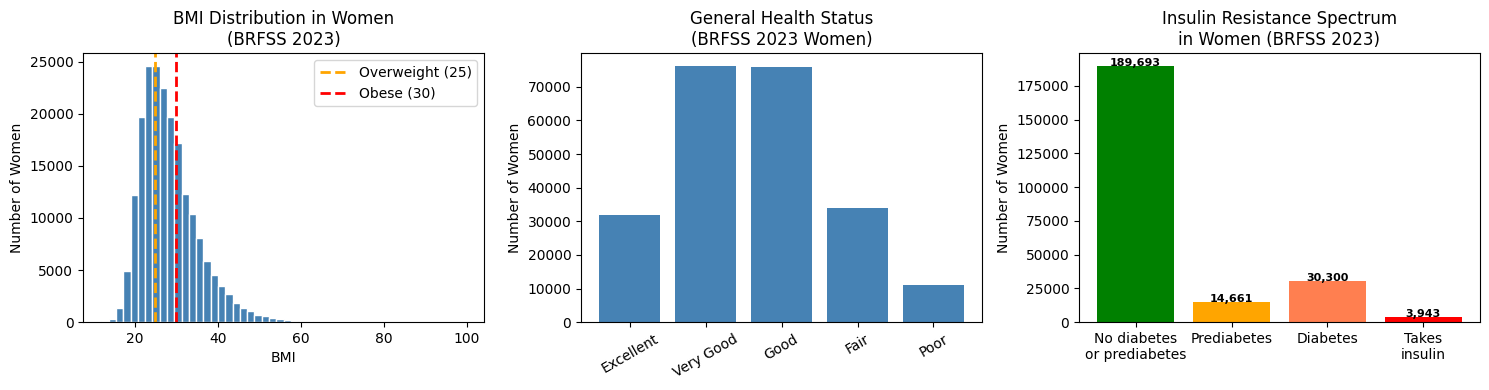

In [9]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

#  BMI Distribution
bmi = df_clean['_BMI5'].dropna() / 100

axes[0].hist(bmi, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(x=25, color='orange', linestyle='--',
                linewidth=2, label='Overweight (25)')
axes[0].axvline(x=30, color='red', linestyle='--',
                linewidth=2, label='Obese (30)')
axes[0].set_title('BMI Distribution in Women\n(BRFSS 2023)')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Number of Women')
axes[0].legend()

# General Health Status
health_labels = {1:'Excellent', 2:'Very Good',
                 3:'Good', 4:'Fair', 5:'Poor'}
health_counts = df_clean['GENHLTH'].value_counts().sort_index()
labels_list = [health_labels.get(int(k), str(k))
               for k in health_counts.index
               if k in health_labels]
values_list = [health_counts[k] for k in health_counts.index
               if k in health_labels]

axes[1].bar(labels_list, values_list, color='steelblue')
axes[1].set_title('General Health Status\n(BRFSS 2023 Women)')
axes[1].set_ylabel('Number of Women')
axes[1].tick_params(axis='x', rotation=30)

#Insulin Resistance Spectrum
if 'INSULIN1' in df_clean.columns and 'PREDIAB2' in df_clean.columns:
    ir_data = {
        'No diabetes\nor prediabetes': (df_clean['DIABETE4'] == 3.0).sum(),
        'Prediabetes': (df_clean['PREDIAB2'].isin([1.0, 2.0])).sum(),
        'Diabetes': (df_clean['DIABETE4'] == 1.0).sum(),
        'Takes\ninsulin': (df_clean['INSULIN1'] == 1.0).sum(),
    }
    colors = ['green', 'orange', 'coral', 'red']
    axes[2].bar(ir_data.keys(), ir_data.values(), color=colors)
    axes[2].set_title('Insulin Resistance Spectrum\nin Women (BRFSS 2023)')
    axes[2].set_ylabel('Number of Women')
    for i, v in enumerate(ir_data.values()):
        axes[2].text(i, v + 200, f'{v:,}', ha='center',
                     fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/brfss_eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()

Build Insulin Resistance features

In [10]:
df_model2 = df_clean.copy()

# Fix BMI — divide by 100 to get real value
df_model2['BMI'] = df_model2['_BMI5'] / 100

# Individual insulin resistance flags
df_model2['takes_insulin'] = (
    df_model2['INSULIN1'] == 1.0
).astype(int)

# Told have prediabetes
df_model2['prediabetes'] = (
    df_model2['PREDIAB2'].isin([1.0, 2.0])
).astype(int)

# Diabetes diagnosis
df_model2['has_diabetes'] = (
    df_model2['DIABETE4'] == 1.0
).astype(int)

# COMBINED insulin resistance flag
df_model2['insulin_resistance'] = (
    (df_model2['takes_insulin'] == 1) |
    (df_model2['prediabetes'] == 1) |
    (df_model2['has_diabetes'] == 1)
).astype(int)

print("INSULIN RESISTANCE BREAKDOWN ")
print(f"Takes insulin        : {df_model2['takes_insulin'].sum():,} women")
print(f"Prediabetes          : {df_model2['prediabetes'].sum():,} women")
print(f"Diabetes             : {df_model2['has_diabetes'].sum():,} women")
print(f"Combined IR flag     : {df_model2['insulin_resistance'].sum():,} women")
print(f"As % of women        : {df_model2['insulin_resistance'].mean()*100:.1f}%")


INSULIN RESISTANCE BREAKDOWN 
Takes insulin        : 3,943 women
Prediabetes          : 14,661 women
Diabetes             : 30,300 women
Combined IR flag     : 44,961 women
As % of women        : 19.6%


Build Proxy Label

In [11]:
# Risk factor 1 :  High BMI (overweight or obese)
# High BMI is linked to insulin resistance
df_model2['high_bmi'] = (df_model2['BMI'] >= 25).astype(int)

# Risk factor 2 : Insulin resistance
# Already built above

# Risk factor 3 — Poor physical health
df_model2['poor_physical_health'] = (
    df_model2['PHYSHLTH'] > 7
).astype(int)

# Risk factor 4 — Poor mental health
df_model2['poor_mental_health'] = (
    df_model2['MENTHLTH'] > 7
).astype(int)

# Risk factor 5 — No health insurance
df_model2['no_insurance'] = (
    df_model2['_HLTHPL1'] == 2.0
).astype(int)

# Risk factor 6 — Physical inactivity
df_model2['inactive'] = (
    df_model2['EXERANY2'] == 2.0
).astype(int)

# Risk factor 7 — Depression diagnosis
df_model2['depression'] = (
    df_model2['ADDEPEV3'] == 1.0
).astype(int)

# ADD UP THE RISK FACTORS
risk_score = (
    df_model2['high_bmi'] +
    df_model2['insulin_resistance'] +
    df_model2['poor_physical_health'] +
    df_model2['poor_mental_health'] +
    df_model2['no_insurance'] +
    df_model2['inactive'] +
    df_model2['depression']
)

# High risk = 3 or more risk factors present
df_model2['high_risk'] = (risk_score >= 3).astype(int)

print("PROXY LABEL RESULTS")
print(f"Total women        : {len(df_model2):,}")
print(f"High risk (1)      : {df_model2['high_risk'].sum():,} ({df_model2['high_risk'].mean()*100:.1f}%)")
print(f"Low risk  (0)      : {(df_model2['high_risk']==0).sum():,} ({(df_model2['high_risk']==0).mean()*100:.1f}%)")
print(f"\nIndividual risk factor counts:")
for col, label in [
    ('high_bmi',            'High BMI (≥25)          '),
    ('insulin_resistance',  'Insulin resistance      '),
    ('poor_physical_health','Poor physical health    '),
    ('poor_mental_health',  'Poor mental health      '),
    ('no_insurance',        'No health insurance     '),
    ('inactive',            'Physically inactive     '),
    ('depression',          'Depression diagnosis    '),
]:
    if col in df_model2.columns:
        count = df_model2[col].sum()
        pct = count / len(df_model2) * 100
        print(f"  {label}: {count:,} ({pct:.1f}%)")

PROXY LABEL RESULTS
Total women        : 229,541
High risk (1)      : 134,365 (58.5%)
Low risk  (0)      : 95,176 (41.5%)

Individual risk factor counts:
  High BMI (≥25)          : 128,779 (56.1%)
  Insulin resistance      : 44,961 (19.6%)
  Poor physical health    : 170,963 (74.5%)
  Poor mental health      : 171,468 (74.7%)
  No health insurance     : 9,725 (4.2%)
  Physically inactive     : 62,278 (27.1%)
  Depression diagnosis    : 58,193 (25.4%)


Correlation Analysis

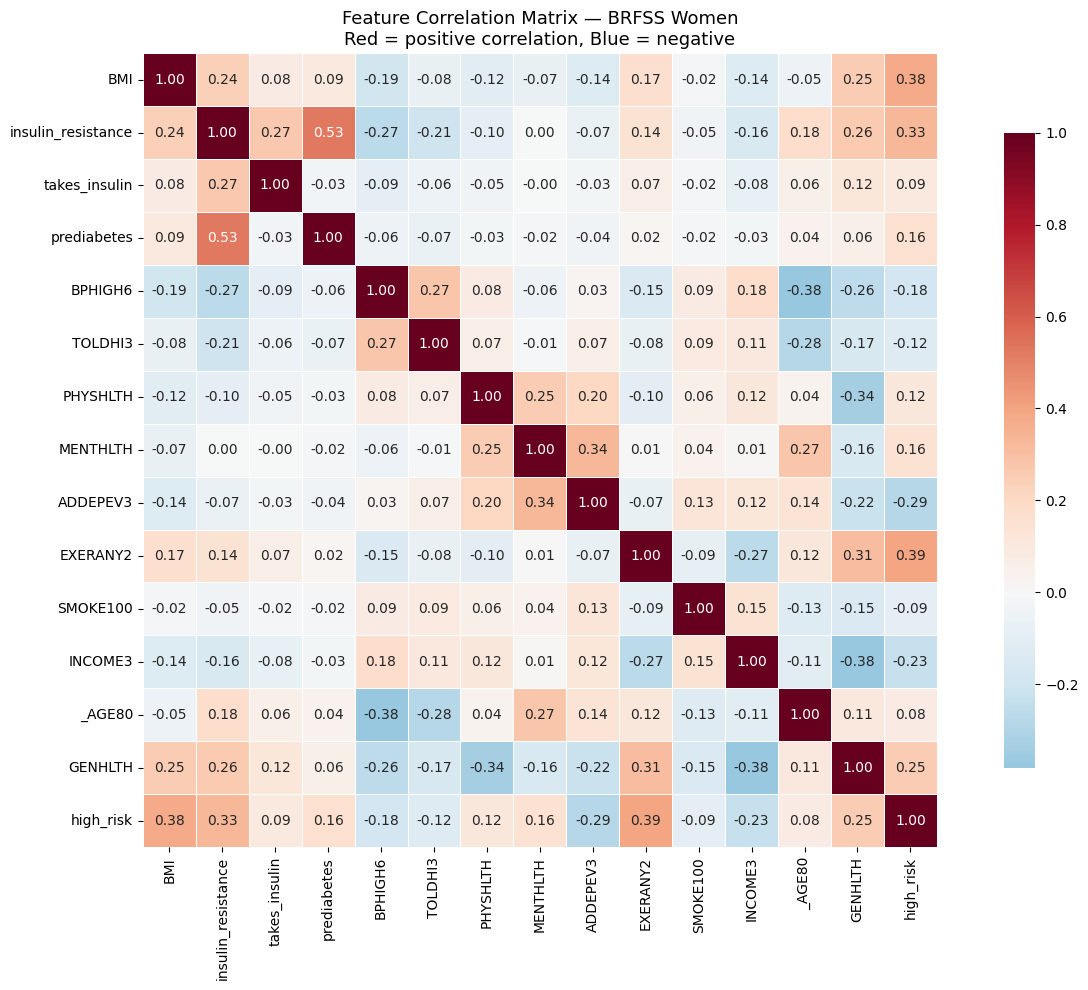

In [12]:
feature_cols = [
    'BMI', 'insulin_resistance', 'takes_insulin', 'prediabetes',
    'BPHIGH6', 'TOLDHI3', 'PHYSHLTH', 'MENTHLTH', 'ADDEPEV3',
    'EXERANY2', 'SMOKE100', 'INCOME3', '_AGE80', 'GENHLTH',
    'high_risk'
]

available = [c for c in feature_cols if c in df_model2.columns]
corr = df_model2[available].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Feature Correlation Matrix — BRFSS Women\n'
          'Red = positive correlation, Blue = negative',
          fontsize=13)
plt.tight_layout()
plt.savefig('outputs/brfss_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()


Feature Importance

Training on 229,541 rows for feature importance...


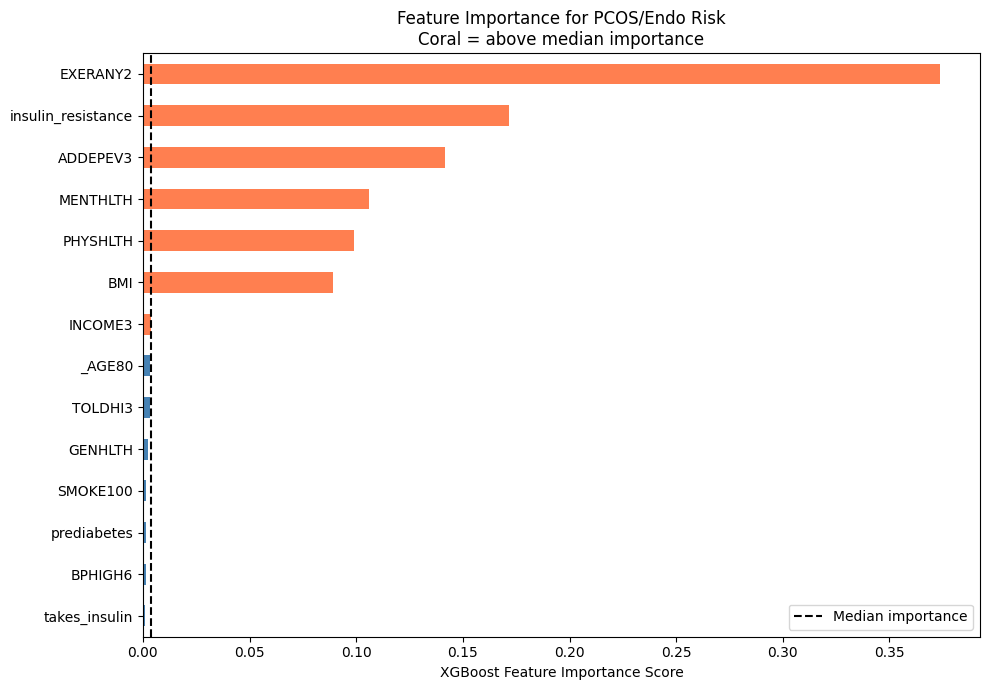


FEATURE IMPORTANCE RANKING
  EXERANY2                  0.3737 █████████████████████████████████████
  insulin_resistance        0.1716 █████████████████
  ADDEPEV3                  0.1417 ██████████████
  MENTHLTH                  0.1058 ██████████
  PHYSHLTH                  0.0992 █████████
  BMI                       0.0891 ████████
  INCOME3                   0.0038 
  _AGE80                    0.0035 
  TOLDHI3                   0.0034 
  GENHLTH                   0.0026 
  SMOKE100                  0.0017 
  prediabetes               0.0015 
  BPHIGH6                   0.0013 
  takes_insulin             0.0011 


In [13]:
from xgboost import XGBClassifier

feature_cols = [
    'BMI', 'insulin_resistance', 'takes_insulin', 'prediabetes',
    'BPHIGH6', 'TOLDHI3', 'PHYSHLTH', 'MENTHLTH', 'ADDEPEV3',
    'EXERANY2', 'SMOKE100', 'INCOME3', '_AGE80', 'GENHLTH'
]

available_features = [c for c in feature_cols if c in df_model2.columns]
X = df_model2[available_features].copy()
y = df_model2['high_risk'].copy()

# Drop rows where target is missing
mask = y.notna()
X = X[mask]
y = y[mask]

print(f"Training on {len(X):,} rows for feature importance...")

model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)
model.fit(X, y)

# Plot feature importance
importance = pd.Series(
    model.feature_importances_,
    index=available_features
).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = ['coral' if v > importance.median()
          else 'steelblue' for v in importance.values]
importance.plot(kind='barh', color=colors)
plt.axvline(x=importance.median(), color='black',
            linestyle='--', label='Median importance')
plt.title('Feature Importance for PCOS/Endo Risk\n'
          'Coral = above median importance', fontsize=12)
plt.xlabel('XGBoost Feature Importance Score')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/brfss_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nFEATURE IMPORTANCE RANKING")
for feat, score in importance.sort_values(ascending=False).items():
    bar = "█" * int(score * 100)
    print(f"  {feat:<25} {score:.4f} {bar}")

FINAL DATASET

In [16]:
save_cols = [
    # Raw columns for rebuilding proxy label
    'BMI',               # real BMI value
    'PHYSHLTH',          # days physical health not good
    'MENTHLTH',          # days mental health not good
    '_HLTHPL1',          # health insurance
    'EXERANY2',          # physical activity
    'ADDEPEV3',          # depression diagnosis
    'BPHIGH6',           # high blood pressure
    'GENHLTH',           # general health status

    # Insulin resistance features
    'insulin_resistance', # combined IR flag
    'takes_insulin',      # active insulin use
    'prediabetes',        # prediabetes diagnosis
    'has_diabetes',       # diabetes diagnosis

    # Individual risk component flags
    'high_bmi',               # BMI >= 25
    'poor_physical_health',   # PHYSHLTH > 7
    'poor_mental_health',     # MENTHLTH > 7
    'no_insurance',           # no health insurance
    'inactive',               # no physical activity
    'depression',             # depression diagnosis

    # Demographics
    '_AGE80',            # age
    '_RACE',             # race/ethnicity
    'INCOME3',           # household income

    # Old proxy label
    'high_risk'
]

# Only keeping columns that actually exist in df_model2
save_available = [c for c in save_cols if c in df_model2.columns]
missing_save = [c for c in save_cols if c not in df_model2.columns]

df_save = df_model2[save_available].copy()

print("SAVING BRFSS FINAL DATASET ")
print(f"Columns saved  : {len(save_available)}")
print(f"Rows saved     : {len(df_save):,}")
if missing_save:
    print(f"Columns not found (skipped): {missing_save}")

print(f"\nColumns included:")
for col in save_available:
    print(f"  {col}")

# Save
save_path = '/content/drive/MyDrive/brfss_model2_final.csv'
df_save.to_csv(save_path, index=False)
print(f"Shape: {df_save.shape}")


SAVING BRFSS FINAL DATASET 
Columns saved  : 22
Rows saved     : 229,541

Columns included:
  BMI
  PHYSHLTH
  MENTHLTH
  _HLTHPL1
  EXERANY2
  ADDEPEV3
  BPHIGH6
  GENHLTH
  insulin_resistance
  takes_insulin
  prediabetes
  has_diabetes
  high_bmi
  poor_physical_health
  poor_mental_health
  no_insurance
  inactive
  depression
  _AGE80
  _RACE
  INCOME3
  high_risk
Shape: (229541, 22)
